# Forecast Evolution Analysis (v2)
This notebook allows the user to interactively plot the "Linus plot" showing forecast evolution for a specific validity date. Tested on *IFS CF*, *AIFS Single*, *IFS ENS* and *AIFS CRPS-ENS* forecasts.

## User Configuration Options

- **Parameter**: Select from dropdown list
- **Forecast Settings**: 
  - Validity date (calendar picker)
  - Validity time (dropdown)
  - Step interval (dropdown)
  - Maximum forecast days (slider)
- **Model Selection**:
  - **Predefined models**: Select from the list of known models (IFS Control, AIFS Single, etc.)
  - **Custom MARS models**: Define your own model by specifying MARS retrieval arguments (`class`, `type`, `stream`, `expver`) plus optional extra keys (`model`, `database`, `grid`, ...)
- **Geographic Area**: Select using the interactive map

### Model Selection Methods

#### Predefined Models
Select one or more models from the list on the left. These have pre-configured MARS retrieval settings and plot styles.

#### Custom MARS Models
Use the panel on the right to add a model by specifying its MARS retrieval arguments:
- **Name**: A display name for the model
- **class**: MARS class (e.g. `od`, `ai`, `rd`, `d1`)
- **type**: Forecast type (`fc`, `cf`, `pf`)
- **stream**: Data stream (`oper`, `enfo`, ...)
- **expver**: Experiment version (optional)
- **Ensemble**: Tick if this is an ensemble (perturbed) forecast
- **Extra MARS arguments**: Add any additional key-value pairs (e.g. `model=aifs-single`, `database=...`, `grid=[0.25,0.25]`)

### Area Selection Methods

#### Polygon Selection
When drawing a polygon, the system creates a bounding box using the northernmost, westernmost, southernmost, and easternmost points of your selection.

#### Point Selection
When selecting a single point, the system creates a ±0.5° box around that location.

In [ ]:
import os
import sys

from diag_evo import (
    setup_interface,
    retrieve_and_store_data,
    plot_forecast_evolution,
    plot_forecast_evolution_static,
    setup_data_directories,
    get_area_string,
)

# Set up the interface and get the widgets dictionary
widgets_dict = setup_interface()

In [2]:
# Optional: override configuration programmatically
ar=[51.39199, 5.69572, 50.11316, 9.43167]
#po= [50.881878, 7.013875]
widgets_dict['config']['area_sub'] = ar
#widgets_dict['config']['point'] = po


In [3]:
# Optional: override configuration programmatically
#widgets_dict['config']['area_sub'] = [63.76772, 12.62371, 62.76772, 13.62371]
#widgets_dict['config']['point'] = [63.26772, 13.123712]
#widgets_dict['config']['max_days'] = 4
#widgets_dict['config']['step_interval'] = 12

In [ ]:
# Optional: add custom models programmatically instead of using the UI
# from diag_evo import register_custom_model
# register_custom_model(
#     name='My Experiment',
#     retrieval_args={
#         'class': 'rd',
#         'type': 'fc',
#         'stream': 'oper',
#         'expver': 'xxxx',
#         'model': 'some-model',
#     },
#     is_ensemble=False,
#     color='#ff6600'
# )

In [3]:
plot_data = retrieve_and_store_data(widgets_dict, base_path)

Retrieving observations...
Retrieving new observation data...
Nearest station (stnid: _DW1H932, elevation: 147.0,lat: 50.71189, lon: 6.79049, distance: 16.94 km, value: 0.00): stnid                   _DW1H932
latitude                50.71189
longitude                6.79049
level                        0.0
date         2026-02-20 12:00:00
elevation                  147.0
value_0                      0.0
distance               16.943816
Name: 1467, dtype: object
OBS value: 0.00
Station ID: _DW1H932
Station elevation: 147.0 m
Station latitude: 50.71189°
Station longitude: 6.79049°
Retrieving climatology from MARS...
mars - WARN - 
mars - WARN - 
MIR environment variables:
MIR_CACHE_PATH={FILE?/ec/cache.1}/cache:{FILE?/ec/cache.2}/cache
MIR_LSM_NAMED=1km.climate.v013
Using MARS binary: /usr/local/apps/mars/versions/6.33.26.4/bin/mars.bin
mars - INFO   - 20260222.202805 - Welcome to MARS
mars - INFO   - 20260222.202805 - MARS_HOME=/usr/local/apps/mars/configs/prod
mars - INFO   - 20260222.

/perm/ecm3468/for_Balazs/diag_evo_v2/evo_modular_settings.py:1341: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_df = pd.concat([reference_row, data_df], ignore_index=True)


In [ ]:
from diag_evo import get_model_plot_settings

# Build a color map for all selected models
color_map = {}
for model_name in widgets_dict['model_widgets'].value:
    plot_cfg = get_model_plot_settings(model_name)
    color_map[model_name] = plot_cfg['color']

widgets_dict['config']['model_colors'] = color_map

In [5]:
widgets_dict['config']['model_colors']['AIFS ENS Control']="#00FF1E"

In [6]:
widgets_dict['config']['model_colors']={'IFS Control': "#dd00ff",
 'AIFS Single': "#93190c",
 'AIFS ENS Control': '#00FF1E',
 'IFS ENS': "#08fff7",
 'AIFS CRPS-ENS': "#2c32a0"}

In [ ]:
area_str = get_area_string(widgets_dict['config']['area_sub'])
date_str = widgets_dict['config']['valid_date'].strftime("%Y%m%d")
_, _, plot_dir = setup_data_directories(base_path, widgets_dict['config']['param'], area_str, date_str)
plot_data['data_df'].to_csv(f'{plot_dir}/plot_data.csv', index=False)

# Create the interactive plot
plot_forecast_evolution(plot_data, widgets_dict, plot_dir, export_html=True)

Plot exported to: /perm/ecm3468/for_Balazs/diag_evo_v2/data_files/tp_N51.32634_W6.44956_S50.32634_E7.44956_20260220/plot_files/forecast_evolution_point_50.8263N_6.9496E_20260220_1200_tp.html


Static plot exported to: /perm/ecm3468/for_Balazs/diag_evo_v2/data_files/tp_N51.32634_W6.44956_S50.32634_E7.44956_20260220/plot_files/forecast_evolution_static_point_50.8263N_6.9496E_20260220_1200_tp.png


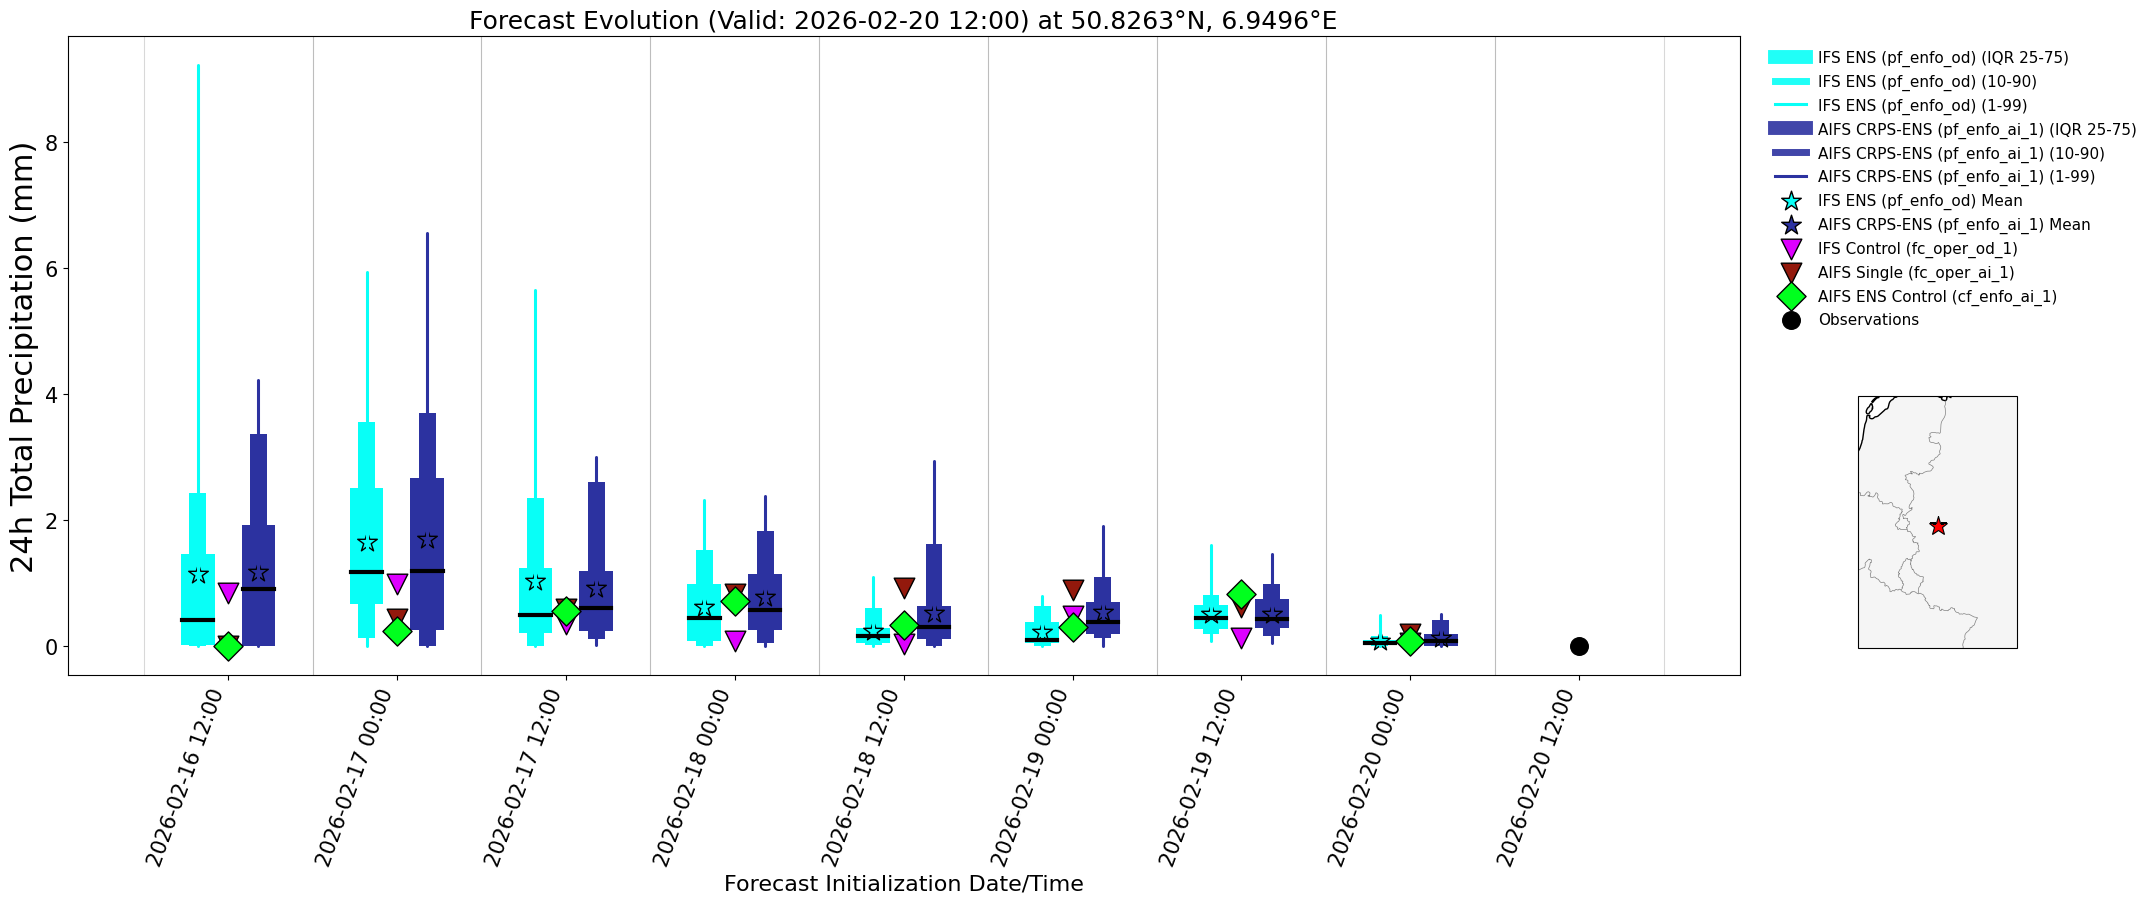

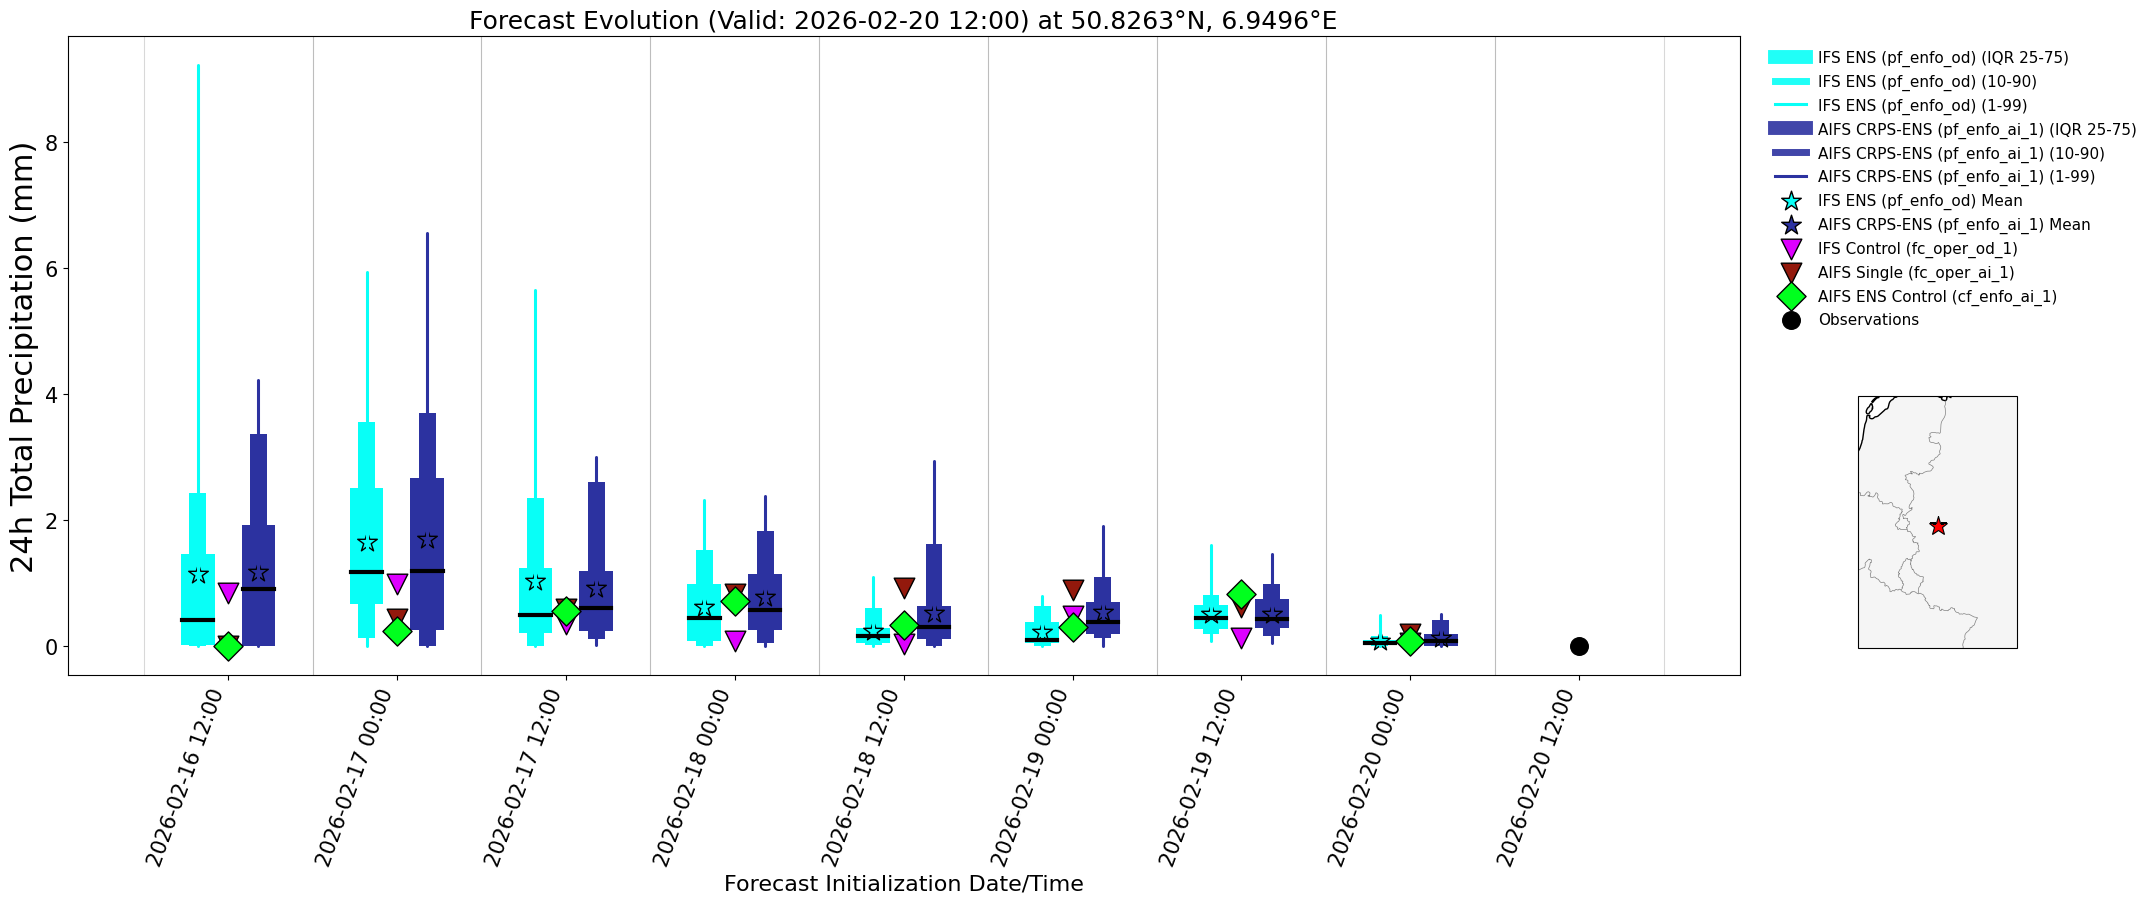

In [8]:
plot_forecast_evolution_static(plot_data, widgets_dict, plot_dir, export_png=True)